# Figure 3 — Linear permeability homogenization

This notebook computes the numerically homogenized permeability of undeformed unit cells with round and hexagonal pores over a range of porosities, and compares the results with dilute and differential estimates.

---

**Authors**

Haotian XIAO
Martin GENET

École Polytechnique, Palaiseau, France


## Imports

In [1]:
from pathlib import Path
import math
import sys

import dolfin
import myPythonLibrary as mypy
import dolfin_mech as dmech

## Project paths

In [2]:
def find_project_dir():
    current_dir = Path.cwd().resolve()

    for candidate in (current_dir, *current_dir.parents):
        if (
            (candidate / "demos").is_dir()
            and (candidate / "src").is_dir()
            and (candidate / "environment.yml").is_file()
        ):
            return candidate

    raise RuntimeError("Could not locate the project directory.")


PROJECT_DIR = find_project_dir()
SRC_DIR = PROJECT_DIR / "src"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_DIR =", PROJECT_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
RESULTS_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/results


## Homogenization function


In [3]:
def run_linear_homogenization_hollowbox(
    r0_list,
    res_folder,
    shape_list=("round", "hex"),
    probe_list=("gx", "gy"),
    pressure_gradient_amplitude=0.01,
    perform_tests=0,
):
    res_folder = Path(res_folder)
    res_folder.mkdir(parents=True, exist_ok=True)

    test = mypy.Test(
        res_folder=str(res_folder),
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    material_parameters = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1.0,
        "eta": 1e-5,
    }

    dim = 2
    n_steps = 1

    def run_one_probe(shape, r0, probe):
        if probe == "gx":
            gx_ini_lst = [0.0]
            gx_fin_lst = [pressure_gradient_amplitude]
            gy_ini_lst = [0.0]
            gy_fin_lst = [0.0]
        elif probe == "gy":
            gx_ini_lst = [0.0]
            gx_fin_lst = [0.0]
            gy_ini_lst = [0.0]
            gy_fin_lst = [pressure_gradient_amplitude]
        else:
            raise ValueError("probe must be 'gx' or 'gy'")

        res_basename = f"linear-{shape}-r0={r0}-{probe}"
        result_basename = res_folder / res_basename
        mesh_filebasename = res_folder / f"mesh-{shape}-r0={r0}"

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"][f"sigma_bar_{i}{j}"] = 0.0

        load_params["solid"]["U_bar_00_lst"] = [0.0]
        load_params["solid"]["U_bar_01_lst"] = [0.0]
        load_params["solid"]["U_bar_10_lst"] = [0.0]
        load_params["solid"]["U_bar_11_lst"] = [0.0]

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst
        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

        load_params["air"]["pf"] = 0.0
        load_params["air"]["pf_lst"] = [0.0] * n_steps

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3.0) / 2.0,
                "xmax": 1.0,
                "ymax": math.sqrt(3.0) / 2.0,
                "r0": r0,
                "l": 0.1,
                "hole_shape": shape,
                "add_center_hole": True,
                "mesh_filebasename": str(mesh_filebasename),
            },
            mat_params={
                "skel": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "bulk": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "pore": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1.0, 0.0),
                        (0.0, 1.0),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs="pbc",
            step_params={
                "n_steps": n_steps,
                "Deltat_lst": [1e-2],
                "dt_ini_lst": [1e-3],
                "dt_min_lst": [1e-4],
                "dt_max_lst": [5e-3],
            },
            load_params=load_params,
            res_basename=str(result_basename),
            verbose=0,
        )

        test.test(str(result_basename))

    for shape in shape_list:
        for r0 in r0_list:
            for probe in probe_list:
                print(f"Running shape={shape}, r0={r0}, probe={probe}")
                run_one_probe(
                    shape=shape,
                    r0=r0,
                    probe=probe,
                )

    return res_folder

## Simulation parameters

In [4]:
r0_list = [0.02, 0.05, 0.072, 0.1, 0.2, 0.315, 0.41, 0.45]
shape_list = ("round", "hex")
probe_list = ("gx", "gy")

res_folder = RESULTS_DIR / "Figure3_linear_homogenization"

## Numerical simulations

In [5]:
run_linear_homogenization_hollowbox(
    r0_list=r0_list,
    res_folder=res_folder,
    shape_list=shape_list,
    probe_list=probe_list,
)

Running shape=round, r0=0.02, probe=gx
Info    : Reconstructing periodicity for curve connection 4 - 8                                                           
Info    : Reconstructing periodicity for curve connection 6 - 2
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Ellipse)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Ellipse)
Info    : [ 50%] Meshing curve 5 (Ellipse)
Info    : [ 60%] Meshing curve 6 (Line) as a copy of curve 2
Info    : [ 70%] Meshing curve 7 (Ellipse)
Info    : [ 80%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Ellipse)
Info    : [100%] Meshing curve 4 (Line) as a copy of curve 8
Info    : Done meshing 1D (Wall 0.000804125s, CPU 0.000264s)
Info    : Meshing 2D...
Info    : Meshing surface 100 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00910012s, CPU 0.006439s)
Info    : Reconstructing periodicity for curve connection 4 - 8
Info    : Reconstructing periodicity for curve connection 6 - 2
Info

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running shape=round, r0=0.02, probe=gy
Info    : Reconstructing periodicity for curve connection 4 - 8                                                           
Info    : Reconstructing periodicity for curve connection 6 - 2
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Ellipse)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Ellipse)
Info    : [ 50%] Meshing curve 5 (Ellipse)
Info    : [ 60%] Meshing curve 6 (Line) as a copy of curve 2
Info    : [ 70%] Meshing curve 7 (Ellipse)
Info    : [ 80%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Ellipse)
Info    : [100%] Meshing curve 4 (Line) as a copy of curve 8
Info    : Done meshing 1D (Wall 0.000224042s, CPU 0.000249s)
Info    : Meshing 2D...
Info    : Meshing surface 100 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00670771s, CPU 0.006696s)
Info    : Reconstructing periodicity for curve connection 4 - 8
Info    : Reconstructing periodicity for curve connection 6 - 2
Info

...

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running shape=hex, r0=0.41, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of cu

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running shape=hex, r0=0.45, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of cu

PosixPath('/Users/xiao/PhD/Project_MicroPoroFlow/results/Figure3_linear_homogenization')

## Post-processing


2026-06-25 21:04:17.170 (  94.251s) [          7D8568]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x161eeede0): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-25 21:04:17.170 (  94.251s) [          7D8568]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x161eeede0): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-25 21:04:17.170 (  94.251s) [          7D8568]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x161eeede0): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-25 21:04:17.170 (  94.251s) [          7D8568]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x161eeede0): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-25 21:04:17.170 (  94.251s) [          7D8568]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x161eeede0): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-25 21:04:17.170 (  94.251s) [          7D8568]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x161eeede0): Unsupported cell type: 56 Sett

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure3_linear_homogenization_K_vs_phi.pdf


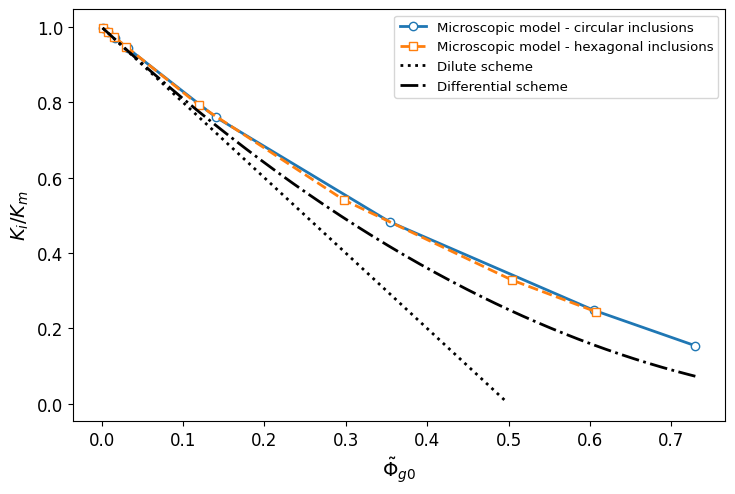

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure3_linear_homogenization_K_vs_phi.pdf
Figure saved in: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure3_linear_homogenization_K_vs_phi.pdf


In [6]:
from Plot_Microporoflow import plot_linear_homogenization_hollowbox

figures_folder = RESULTS_DIR / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

figure_path = figures_folder / "Figure3_linear_homogenization_K_vs_phi.pdf"

plot_linear_homogenization_hollowbox(
    res_folder=str(res_folder),
    shape_list=shape_list,
    r0_list=r0_list,
    save_name=str(figure_path),
    show_plot=True,
)

print("Figure saved in:", figure_path)